In [2]:
import numpy as np
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input, decode_predictions
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt 

In [3]:
# 1. Load the model (pre-trained on the ImageNet dataset)
model = VGG16(weights='imagenet')

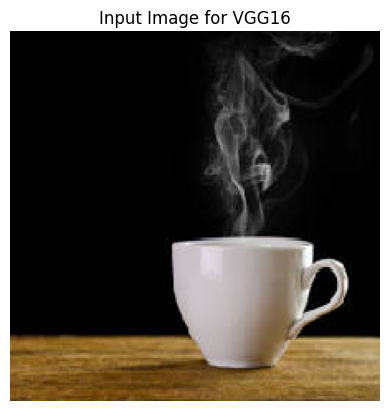

In [4]:
# 2. Load your image (ensure it is 224x224 pixels, as VGG16 requires)
img_path = 'images/coffee.jpeg' # Replace with your image file path
img = image.load_img(img_path, target_size=(224, 224))
#display the input image
plt.imshow(img)
plt.axis('off') 
plt.title("Input Image for VGG16")
plt.show()

In [5]:
# 3. Convert image to a format the computer understands (an array)
x = image.img_to_array(img)
x = np.expand_dims(x, axis=0) # Add a 'batch' dimension
x = preprocess_input(x)       # Adjust colors to match what VGG16 expects

In [6]:
# 4. Make a prediction!
preds = model.predict(x)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 595ms/step


In [7]:
# 5. Convert the math results into human-readable labels
results = decode_predictions(preds, top=3)[0]
print(results)

[('n07930864', 'cup', np.float32(0.8838592)), ('n03063599', 'coffee_mug', np.float32(0.08026334)), ('n07920052', 'espresso', np.float32(0.025598178))]


In [8]:
# 6. Loop through the results to print them cleanly
for i, (imagenet_id, label, score) in enumerate(results):
    # Score is a decimal (e.g., 0.98), so we multiply by 100 for a percentage
    print(f"{i + 1}. {label}: {score * 100:.2f}%")

1. cup: 88.39%
2. coffee_mug: 8.03%
3. espresso: 2.56%
